# Predicción y Simulación del Mundial de Fútbol 2026 mediante Machine Learning

# Resumen

Este proyecto tiene como objetivo desarrollar un sistema capaz de predecir resultados de partidos internacionales y simular el desarrollo completo del Mundial de Fútbol 2026 utilizando técnicas de Machine Learning.

A partir de datos históricos de selecciones nacionales, rankings FIFA y estadísticas de rendimiento, se construyeron modelos predictivos capaces de estimar la fortaleza relativa de cada selección.

Posteriormente se desarrolló una simulación completa del torneo mediante técnicas Monte Carlo, permitiendo calcular las probabilidades de que cada selección alcance las distintas fases del campeonato y estimar el posible campeón del torneo.

Además, se implementó una aplicación interactiva en Streamlit que permite visualizar grupos, comparar selecciones y consultar las probabilidades obtenidas.


# 1. Objetivos

## Objetivo principal

Desarrollar un sistema predictivo basado en Machine Learning capaz de simular el Mundial de Fútbol 2026 y estimar las probabilidades de éxito de cada selección participante.

## Objetivos específicos

- Recopilar información histórica de selecciones nacionales.
- Limpiar y preparar los datos.
- Unificar nombres de selecciones.
- Realizar análisis exploratorio.
- Construir variables relevantes.
- Entrenar diferentes modelos predictivos.
- Comparar métricas de rendimiento.
- Seleccionar el mejor modelo.
- Simular el Mundial completo.
- Calcular probabilidades de clasificación en cada ronda.
- Desarrollar una aplicación interactiva para visualizar resultados.


# 2. Descripción de los Datos

Para el desarrollo del proyecto se utilizaron distintos conjuntos de datos relacionados con el rendimiento histórico de las selecciones nacionales.

Entre la información recopilada se encuentran:

- Resultados históricos de partidos internacionales.
- Rankings FIFA.
- Estadísticas ofensivas.
- Estadísticas defensivas.
- Resultados recientes.
- Información de competiciones internacionales.

La combinación de estas fuentes permitió construir un conjunto de datos suficientemente representativo para el entrenamiento de modelos predictivos.


# Datasets Utilizados

Para el desarrollo del proyecto se partió de varias fuentes de datos externas que contienen información histórica sobre selecciones nacionales de fútbol. Posteriormente, durante las fases de limpieza, integración y simulación, se generaron nuevos conjuntos de datos derivados.

## Datasets originales

| Archivo CSV | Descripción | Uso principal |
|------------|------------|---------------|
| results.csv | Historial de partidos internacionales disputados entre selecciones nacionales desde finales del siglo XIX hasta la actualidad | Entrenamiento del modelo y análisis histórico |
| fifa_ranking.csv | Ranking FIFA de las selecciones nacionales | Medición de la fortaleza actual de los equipos |
| elo.csv | Ranking Elo de selecciones nacionales | Variable adicional para evaluar el nivel competitivo de cada selección |

### Descripción de las fuentes

Todos los csv son de Kaggel.

**results.csv**

Contiene información histórica de partidos internacionales incluyendo:

- Fecha del partido.
- Selección local.
- Selección visitante.
- Goles anotados por cada equipo.
- Torneo disputado.
- País anfitrión.

Este dataset constituye la principal fuente de información utilizada para entrenar los modelos de Machine Learning.

**fifa_ranking.csv**

Incluye la clasificación oficial FIFA de las selecciones nacionales, proporcionando una medida objetiva del rendimiento reciente de cada equipo.

**elo.csv**

Contiene las puntuaciones Elo de las selecciones nacionales. El sistema Elo es ampliamente utilizado para estimar la fuerza relativa de equipos deportivos y aporta una valoración complementaria al ranking FIFA.

---

## Datasets generados durante el proyecto

A partir de los datasets originales se construyeron nuevos conjuntos de datos para facilitar el entrenamiento de modelos y la simulación del Mundial.

| Dataset generado | Descripción |
|------------------|-------------|
| dataset_limpio.csv | Datos históricos tras el proceso de limpieza y normalización |
| dataset_modelo.csv | Dataset final utilizado para entrenar los modelos de Machine Learning |
| grupos_mundial.csv | Configuración de grupos utilizada en la simulación |
| probabilidades_mundial.csv | Probabilidades obtenidas tras las simulaciones Monte Carlo |
| resultados_simulacion.csv | Resultados agregados de las simulaciones del torneo |

---

## Integración de los datos

Los tres datasets originales fueron combinados utilizando el nombre normalizado de cada selección nacional.

El proceso seguido fue:

1. Limpieza de resultados históricos.
2. Homogeneización de nombres de selecciones.
3. Integración del ranking FIFA.
4. Integración del ranking Elo.
5. Construcción de variables estadísticas.
6. Generación del dataset final para Machine Learning.
7. Simulación completa del Mundial 2026.

# 3. Limpieza y Preparación de Datos

Antes de iniciar el entrenamiento fue necesario realizar un proceso de preprocesamiento de datos.

## Eliminación de valores nulos

Se identificaron registros incompletos y se aplicaron técnicas de limpieza para garantizar la calidad de la información.

## Eliminación de duplicados

Se eliminaron registros repetidos para evitar sesgos en el entrenamiento.

## Corrección de formatos

Se unificaron:

- Fechas.
- Formatos numéricos.
- Nombres de columnas.
- Variables categóricas.

## Verificación de consistencia

Se revisó la coherencia de resultados, marcadores y estadísticas.


# Ejemplo con el csv de results

# Inspección inicial

Antes de realizar cualquier transformación es necesario analizar la estructura del dataset para conocer:

- Número de filas y columnas.
- Tipos de datos.
- Valores nulos.
- Coherencia general de la información.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
results = pd.read_csv("data/raw/results.csv")


In [41]:
results.shape

(49287, 9)

In [42]:
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [43]:
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49287 non-null  str    
 1   home_team   49287 non-null  str    
 2   away_team   49287 non-null  str    
 3   home_score  49215 non-null  float64
 4   away_score  49215 non-null  float64
 5   tournament  49287 non-null  str    
 6   city        49287 non-null  str    
 7   country     49287 non-null  str    
 8   neutral     49287 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 5.9 MB


In [44]:
results.describe(include="all")

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
count,49287,49287,49287,49215.000000,49215.000000,49287,49287,49287,49287
unique,16434,325,318,NaN,NaN,193,2132,269,2
top,2012-02-29,Brazil,Uruguay,NaN,NaN,Friendly,Kuala Lumpur,United States,False
freq,66,614,584,NaN,NaN,18252,739,1531,36248
mean,NaN,NaN,NaN,1.756091,1.182404,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,1.770617,1.401770,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN


In [45]:
results.isnull().sum()

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [46]:
results[
    results["home_score"].isna() |
    results["away_score"].isna()
].shape

(72, 9)

In [47]:
results = results.dropna(
    subset=["home_score", "away_score"]
)

In [48]:
results.isnull().sum()

date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

# Análisis temporal del dataset

Se analiza el periodo temporal cubierto por el dataset para determinar qué años serán utilizados durante el entrenamiento.

In [49]:
results["date"].min()

'1872-11-30'

In [50]:
results["date"].max()

'2026-03-31'

In [51]:
# Filtrar periodo
results_2000_2025 = results[
    (results['date'] >= '2000-01-01') &
    (results['date'] <= '2025-12-31')
]

# Número de filas
print(f"Número de partidos: {results_2000_2025.shape[0]}")

Número de partidos: 24992


# Análisis de selecciones participantes

Se revisan los nombres de las selecciones para detectar posibles inconsistencias que puedan afectar a la integración con otros datasets.

In [52]:
sorted(results["home_team"].unique())

['Abkhazia',
 'Afghanistan',
 'Albania',
 'Alderney',
 'Algeria',
 'American Samoa',
 'Andalusia',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Arameans Suryoye',
 'Argentina',
 'Armenia',
 'Artsakh',
 'Aruba',
 'Australia',
 'Austria',
 'Aymara',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barawa',
 'Barbados',
 'Basque Country',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Biafra',
 'Bolivia',
 'Bonaire',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brittany',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Canary Islands',
 'Cape Verde',
 'Cascadia',
 'Catalonia',
 'Cayman Islands',
 'Central African Republic',
 'Central Spain',
 'Chad',
 'Chagos Islands',
 'Chameria',
 'Chechnya',
 'Chile',
 'China PR',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Corsica',
 'Costa Rica',
 'County of Nice',
 'Croatia',
 'Cuba',
 'Curaçao',
 'Cyprus',
 'Czech 

# Análisis de competiciones

Se analiza la variable tournament para identificar las competiciones
presentes en el dataset.

Esta información permitirá posteriormente construir una variable que
represente la importancia relativa de cada torneo, mejorando la capacidad
predictiva de los modelos.

In [53]:
results["tournament"].value_counts()

tournament
Friendly                                18252
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                            964
                                        ...  
TIFOCO Tournament                           1
Copa Confraternidad                         1
Benedikt Fontana Cup                        1
ConIFA Challenger Cup                       1
South Asian Super Cup                       1
Name: count, Length: 193, dtype: int64

# Selección preliminar de variables

Se identifican las variables potencialmente relevantes para el modelado.

Variables candidatas:

- date
- home_team
- away_team
- home_score
- away_score
- tournament
- neutral

Variables potencialmente descartables:

- city
- country

La decisión definitiva se tomará tras la fase de ingeniería de características.

#  Creación de la variable objetivo

La variable objetivo del proyecto será la diferencia de goles entre ambos equipos.

goal_diff = home_score - away_score

Esta variable permite representar victorias, empates y derrotas mediante una única variable numérica.

In [54]:
results["goal_diff"] = (
    results["home_score"]
    - results["away_score"]
)

In [55]:
results[
    [
        "home_score",
        "away_score",
        "goal_diff"
    ]
].head()

,home_score,away_score,goal_diff
0,0.0,0.0,0.0
1,4.0,2.0,2.0
2,2.0,1.0,1.0
3,2.0,2.0,0.0
4,3.0,0.0,3.0


# Selección de variables finales

Tras el análisis exploratorio se seleccionan las variables que serán utilizadas durante las fases posteriores del proyecto.

Variables conservadas:

- date
- home_team
- away_team
- home_score
- away_score
- tournament
- neutral
- goal_diff

Las variables city y country se descartan debido a que no aportan información relevante para el objetivo del proyecto y podrían introducir una complejidad innecesaria.

In [56]:
results_clean = results[
    [
        "date",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "tournament",
        "neutral",
        "goal_diff"
    ]
]

In [57]:
results_clean.head()

,date,home_team,away_team,home_score,away_score,tournament,neutral,goal_diff
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,False,0.0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,False,2.0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,False,1.0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,False,0.0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,False,3.0


# Filtrado temporal definitivo

Con el objetivo de representar el fútbol moderno y garantizar la disponibilidad de todas las variables auxiliares (Ranking FIFA y Elo), se seleccionan únicamente los partidos disputados entre los años 2000 y 2025.

In [58]:
results_clean = results_clean[
    (results_clean["date"] >= "2000-01-01") &
    (results_clean["date"] <= "2025-12-31")
]

In [59]:
results_clean["date"].min()

'2000-01-04'

In [60]:
results_clean["date"].max()

'2025-12-31'

In [61]:
results_clean.shape

(24992, 8)

Tras realizar la limpieza y estudio del dataset, se guardo,  y se realizaron las mismas operaciones con los csv de ranking y elo.

# 4. Homogeneización de Selecciones

Durante la integración de los distintos datasets se detectó que algunas selecciones aparecían con nombres diferentes según la fuente de información utilizada.

Para evitar errores durante la combinación de datos se creó una tabla de equivalencias que permitiera unificar todas las selecciones bajo una única denominación.

| Nombre original | Nombre normalizado |
|----------------|-------------------|
| USA | United States |
| Korea Republic | South Korea |
| Türkiye | Turkey |
| Côte d'Ivoire | Ivory Coast |
| IR Iran | Iran |
| Cabo Verde | Cape Verde |
| Democratic Republic of Congo | DR Congo |
| Curaçao | Curacao |

La homogeneización de nombres permitió integrar correctamente los rankings FIFA, rankings Elo y resultados históricos, evitando la aparición de registros duplicados o selecciones tratadas como equipos diferentes.


# 5. Análisis Exploratorio de Datos (EDA)

Una vez preparados los datos se realizó un análisis exploratorio con el objetivo de comprender mejor el comportamiento de las selecciones.

## Aspectos analizados

### Distribución de victorias

Análisis de la frecuencia de victorias obtenidas por cada selección.

### Distribución de goles

Estudio del comportamiento ofensivo de los equipos.

### Rendimiento defensivo

Comparación de goles encajados.

### Rankings FIFA

Relación entre ranking y rendimiento histórico.

### Comparación entre selecciones

Análisis de las principales candidatas al título.


In [62]:
dataset = pd.read_csv(
    "data/processed/dataset_mundial_final.csv"
)

In [63]:
dataset.head()

,date,home_team,away_team,home_score,away_score,tournament,tournament_weight,neutral,goal_diff,fifa_rank_home,...,home_last5_goals_against,home_last5_goal_balance,away_last5_points,away_last5_goals_for,away_last5_goals_against,away_last5_goal_balance,form_points_diff,form_goals_for_diff,form_goals_against_diff,form_goal_balance_diff
0,2000-03-19,Cayman Islands,Cuba,0.0,0.0,FIFA World Cup qualification,6,False,0.0,149.0,...,1.0,-1.0,5.0,8.0,7.0,1.0,-4.0,-8.0,-6.0,-2.0
1,2000-03-19,Dominica,Haiti,1.0,3.0,FIFA World Cup qualification,6,False,-2.0,152.0,...,0.0,2.0,7.0,5.0,12.0,-7.0,-4.0,-3.0,-12.0,9.0
2,2000-03-19,Bermuda,British Virgin Islands,9.0,0.0,FIFA World Cup qualification,6,False,9.0,157.0,...,2.0,-2.0,3.0,4.0,8.0,-4.0,-3.0,-4.0,-6.0,2.0
3,2000-03-25,Bahrain,Jordan,1.0,1.0,Friendly,1,False,0.0,139.0,...,1.0,0.0,8.0,6.0,5.0,1.0,-5.0,-5.0,-4.0,-1.0
4,2000-03-25,Zambia,Botswana,3.0,0.0,COSAFA Cup,3,False,3.0,38.0,...,5.0,1.0,4.0,4.0,8.0,-4.0,2.0,2.0,-3.0,5.0


In [64]:
dataset.describe()

,home_score,away_score,tournament_weight,goal_diff,fifa_rank_home,fifa_points_home,fifa_rank_away,fifa_points_away,elo_home,elo_away,...,home_last5_goals_against,home_last5_goal_balance,away_last5_points,away_last5_goals_for,away_last5_goals_against,away_last5_goal_balance,form_points_diff,form_goals_for_diff,form_goals_against_diff,form_goal_balance_diff
count,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,...,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000
mean,1.554397,1.062643,4.037029,0.491753,75.986565,807.757379,79.481267,790.353762,1546.388367,1523.356745,...,5.178864,2.772966,5.540797,5.396450,7.669252,-2.272802,2.928017,2.555380,-2.490388,5.045767
std,1.515361,1.207853,2.559755,2.095620,52.466815,468.075220,52.416028,459.662314,280.065503,280.509532,...,3.256668,5.820964,3.344356,3.168982,4.233819,6.029459,4.533001,4.838533,4.967477,7.789455
min,0.000000,0.000000,1.000000,-14.000000,1.000000,0.000000,1.000000,0.000000,497.000000,497.000000,...,0.000000,-45.000000,0.000000,0.000000,0.000000,-42.000000,-14.000000,-22.000000,-38.000000,-38.000000
25%,0.000000,0.000000,1.000000,-1.000000,31.000000,418.000000,36.000000,414.000000,1360.000000,1340.000000,...,3.000000,-1.000000,3.000000,3.000000,5.000000,-6.000000,0.000000,-1.000000,-5.000000,0.000000
50%,1.000000,1.000000,4.000000,0.000000,69.000000,714.000000,72.000000,692.000000,1565.000000,1543.000000,...,5.000000,3.000000,5.000000,5.000000,7.000000,-2.000000,3.000000,2.000000,-2.000000,5.000000
75%,2.000000,2.000000,6.000000,2.000000,113.000000,1203.945000,116.000000,1179.000000,1747.000000,1726.000000,...,7.000000,6.000000,8.000000,7.000000,10.000000,2.000000,6.000000,5.000000,1.000000,10.000000
max,17.000000,14.000000,10.000000,17.000000,211.000000,2164.000000,211.000000,2164.000000,2171.000000,2167.000000,...,48.000000,36.000000,15.000000,27.000000,43.000000,25.000000,15.000000,33.000000,38.000000,59.000000


In [65]:
dataset.isna().sum()

date                        0
home_team                   0
away_team                   0
home_score                  0
away_score                  0
tournament                  0
tournament_weight           0
neutral                     0
goal_diff                   0
fifa_rank_home              0
fifa_points_home            0
fifa_rank_away              0
fifa_points_away            0
elo_home                    0
elo_away                    0
fifa_rank_diff              0
fifa_points_diff            0
elo_diff                    0
home_last5_points           0
home_last5_goals_for        0
home_last5_goals_against    0
home_last5_goal_balance     0
away_last5_points           0
away_last5_goals_for        0
away_last5_goals_against    0
away_last5_goal_balance     0
form_points_diff            0
form_goals_for_diff         0
form_goals_against_diff     0
form_goal_balance_diff      0
dtype: int64

 ## Análisis de la variable objetivo

La variable objetivo del problema es la diferencia de goles.

Valores positivos indican victoria del equipo local.

Valores negativos indican victoria del equipo visitante.

El valor cero representa empate.

In [66]:
dataset["goal_diff"].describe()

count    18310.000000
mean         0.491753
std          2.095620
min        -14.000000
25%         -1.000000
50%          0.000000
75%          2.000000
max         17.000000
Name: goal_diff, dtype: float64

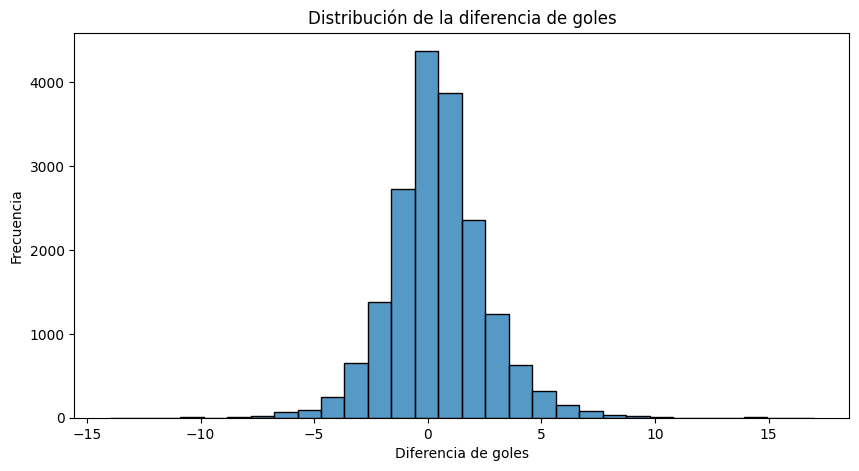

In [67]:
plt.figure(figsize=(10,5))

sns.histplot(
    dataset["goal_diff"],
    bins=30
)

plt.title("Distribución de la diferencia de goles")
plt.xlabel("Diferencia de goles")
plt.ylabel("Frecuencia")

plt.savefig(
    "histograma_goal_diff.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

La distribución de la diferencia de goles se concentra alrededor del valor 0.

Esto indica que la mayoría de los partidos internacionales suelen resolverse por márgenes reducidos, mientras que las goleadas representan una proporción mucho menor de los encuentros.

La distribución presenta una forma aproximadamente simétrica, lo que justifica el uso de técnicas de regresión para modelar esta variable objetivo.

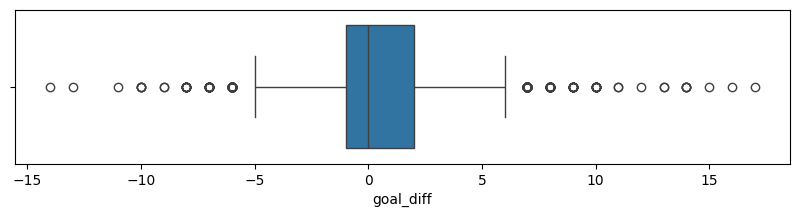

In [68]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=dataset["goal_diff"]
)

plt.show()

Se observan algunos valores extremos asociados a goleadas poco frecuentes.

Sin embargo, la mayor parte de los partidos se concentra en diferencias de goles cercanas a cero.

Estos resultados son coherentes con el comportamiento habitual del fútbol internacional y no justifican la eliminación de los valores extremos, ya que representan resultados reales observados en competición.

## Conclusiones preliminares

El dataset final contiene 16.704 partidos internacionales disputados entre 2000 y 2025.

No existen valores faltantes y todas las variables necesarias para el modelado están disponibles.

Se ha realizado una primera inspección de la variable objetivo (goal_diff), observándose una distribución centrada en valores próximos al empate, con presencia de algunas goleadas extremas menos frecuentes.

El análisis detallado de correlaciones y selección de variables se realizará en las siguientes fases del proyecto.

## Correlación entre variables

Se estudian las relaciones lineales entre las variables numéricas para detectar redundancias y posibles problemas de multicolinealidad.

In [71]:
numeric_cols = dataset.select_dtypes(
    include=np.number
).columns

numeric_cols

Index(['home_score', 'away_score', 'tournament_weight', 'goal_diff',
       'fifa_rank_home', 'fifa_points_home', 'fifa_rank_away',
       'fifa_points_away', 'elo_home', 'elo_away', 'fifa_rank_diff',
       'fifa_points_diff', 'elo_diff', 'home_last5_points',
       'home_last5_goals_for', 'home_last5_goals_against',
       'home_last5_goal_balance', 'away_last5_points', 'away_last5_goals_for',
       'away_last5_goals_against', 'away_last5_goal_balance',
       'form_points_diff', 'form_goals_for_diff', 'form_goals_against_diff',
       'form_goal_balance_diff'],
      dtype='str')

In [72]:
corr = dataset[numeric_cols].corr()

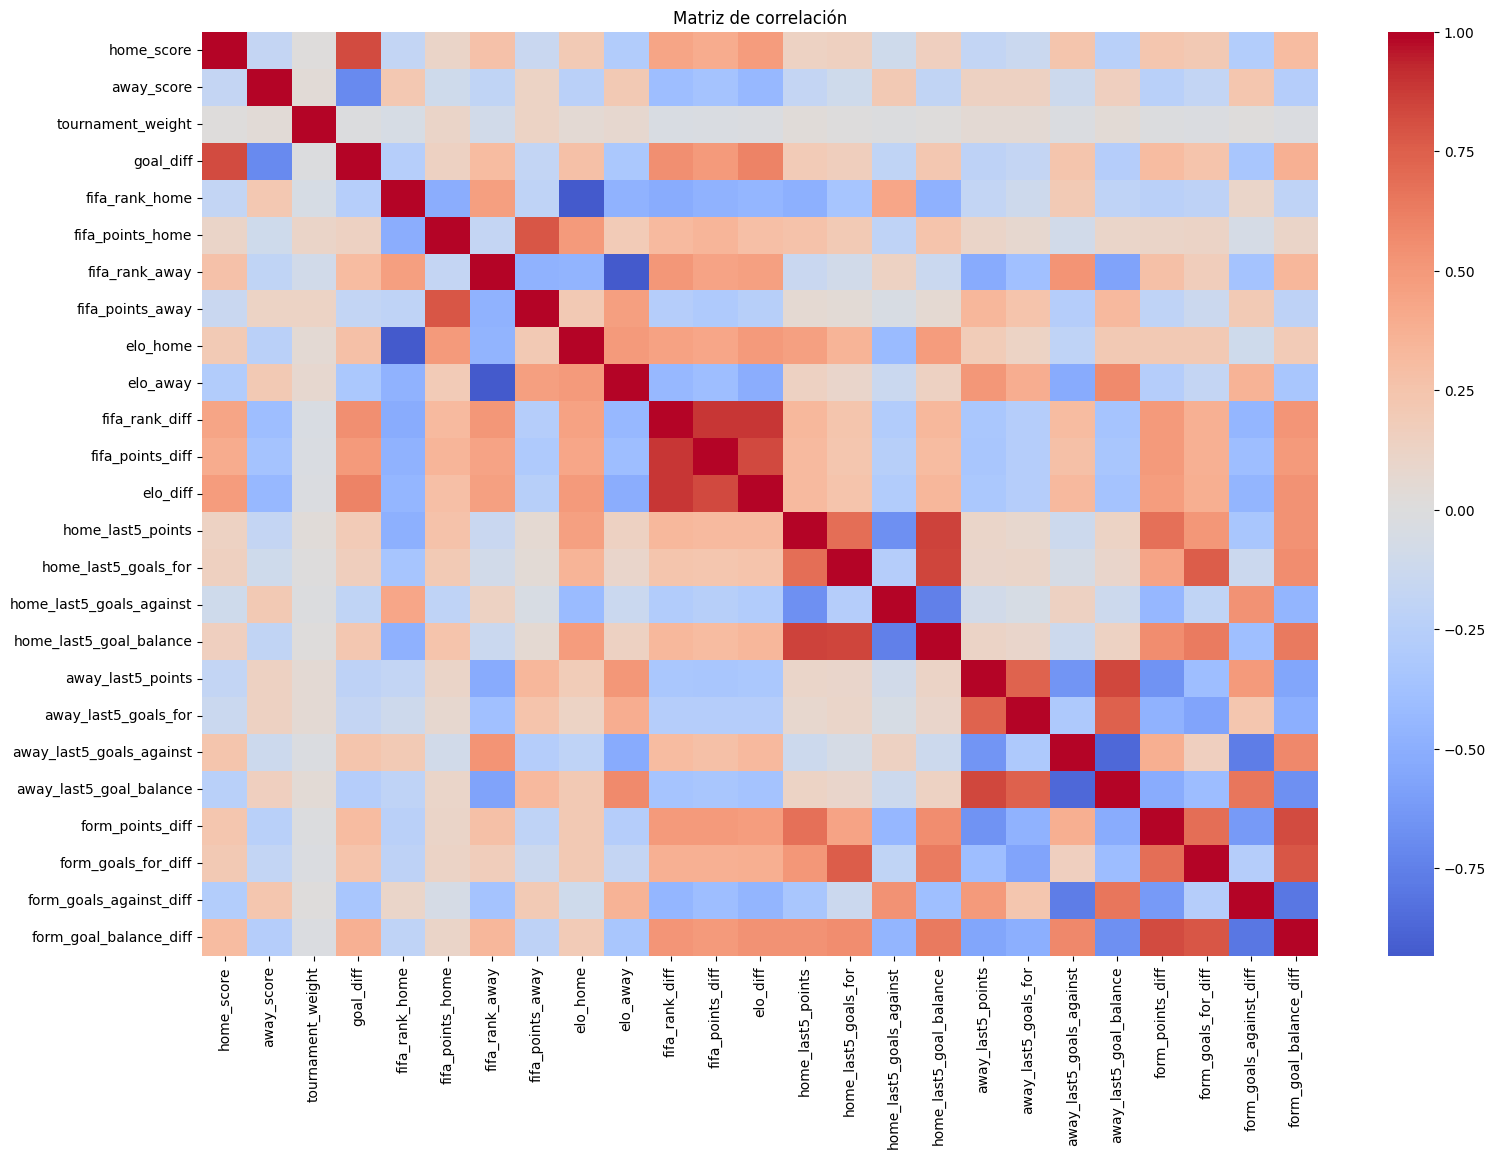

In [73]:
plt.figure(figsize=(18,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")
plt.show()

La matriz de correlación permite identificar relaciones lineales entre las variables del dataset.

Se observa una fuerte relación entre variables derivadas de una misma fuente de información, especialmente entre las métricas FIFA y Elo.

Asimismo, algunas variables relacionadas con el rendimiento reciente presentan correlaciones moderadas con la diferencia de goles, lo que sugiere que pueden aportar capacidad predictiva al modelo.

In [74]:
corr_goal = (
    corr["goal_diff"]
    .sort_values(ascending=False)
)

corr_goal

goal_diff                   1.000000
home_score                  0.823309
elo_diff                    0.604010
fifa_rank_diff              0.548899
fifa_points_diff            0.497507
form_goal_balance_diff      0.375211
form_points_diff            0.310295
fifa_rank_away              0.308379
elo_home                    0.278603
form_goals_for_diff         0.255156
away_last5_goals_against    0.245799
home_last5_goal_balance     0.226679
home_last5_points           0.199047
home_last5_goals_for        0.167550
fifa_points_home            0.146201
tournament_weight          -0.010308
away_last5_goals_for       -0.177512
fifa_points_away           -0.178470
home_last5_goals_against   -0.198805
away_last5_points          -0.215451
fifa_rank_home             -0.259441
away_last5_goal_balance    -0.265894
elo_away                   -0.327574
form_goals_against_diff    -0.339832
away_score                 -0.702080
Name: goal_diff, dtype: float64

## Distribución del rating Elo

El sistema Elo es una de las variables más importantes del modelo. Analizamos cómo se distribuyen las puntuaciones Elo de las selecciones presentes en el dataset.

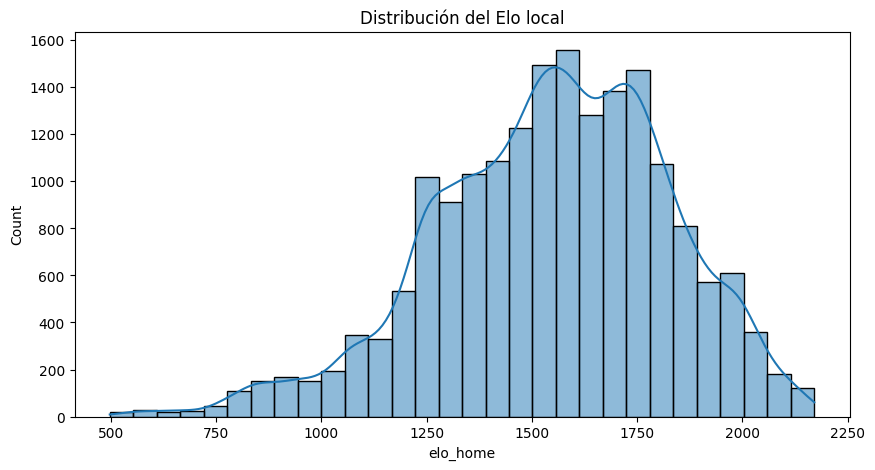

In [75]:
plt.figure(figsize=(10,5))

sns.histplot(
    dataset["elo_home"],
    bins=30,
    kde=True
)

plt.title(
    "Distribución del Elo local"
)

plt.show()

La distribución de puntuaciones Elo presenta una concentración en valores intermedios y una menor presencia de selecciones con puntuaciones extremadamente altas o bajas.

Esto refleja la existencia de un grupo reducido de selecciones de élite y una mayor cantidad de equipos con niveles competitivos similares.

## Distribución Ranking FIFA

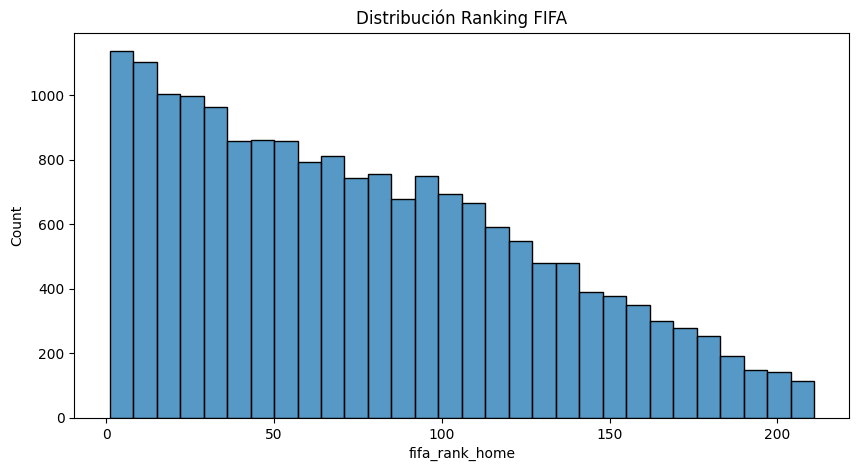

In [76]:
plt.figure(figsize=(10,5))

sns.histplot(
    dataset["fifa_rank_home"],
    bins=30
)

plt.title(
    "Distribución Ranking FIFA"
)

plt.show()

La distribución del ranking FIFA muestra una representación amplia de selecciones pertenecientes a distintos niveles competitivos.

Esto resulta positivo para el entrenamiento del modelo, ya que permite aprender patrones tanto de enfrentamientos equilibrados como de partidos con diferencias significativas de nivel.

## Relación entre Elo y rendimiento deportivo

Se analiza la relación entre la diferencia Elo entre dos selecciones y la diferencia real de goles obtenida en el partido.

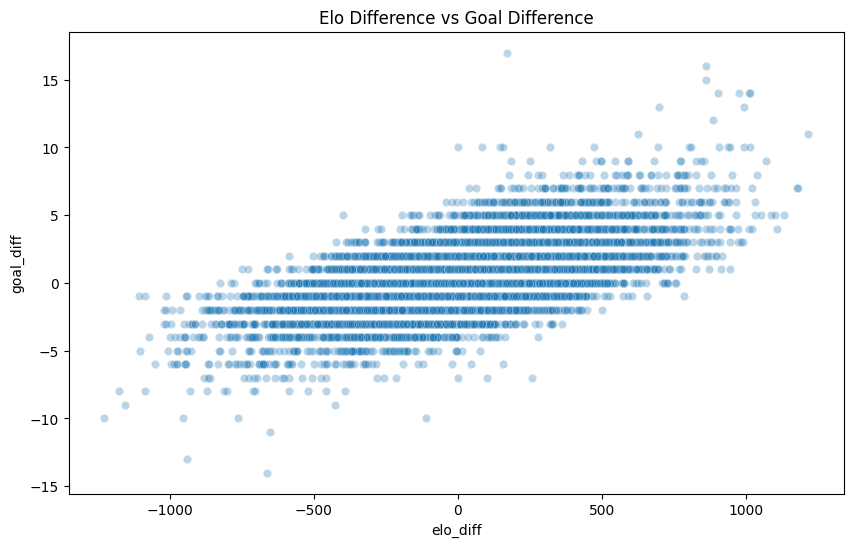

In [77]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=dataset,
    x="elo_diff",
    y="goal_diff",
    alpha=0.3
)

plt.title(
    "Elo Difference vs Goal Difference"
)

plt.show()

Se aprecia una tendencia positiva entre la diferencia Elo y la diferencia de goles observada.

En general, cuando una selección presenta una ventaja importante en Elo sobre su rival, tiende a obtener mejores resultados deportivos.

No obstante, la dispersión de los puntos evidencia la existencia de una elevada incertidumbre inherente al fútbol, lo que justifica la incorporación de un componente aleatorio.

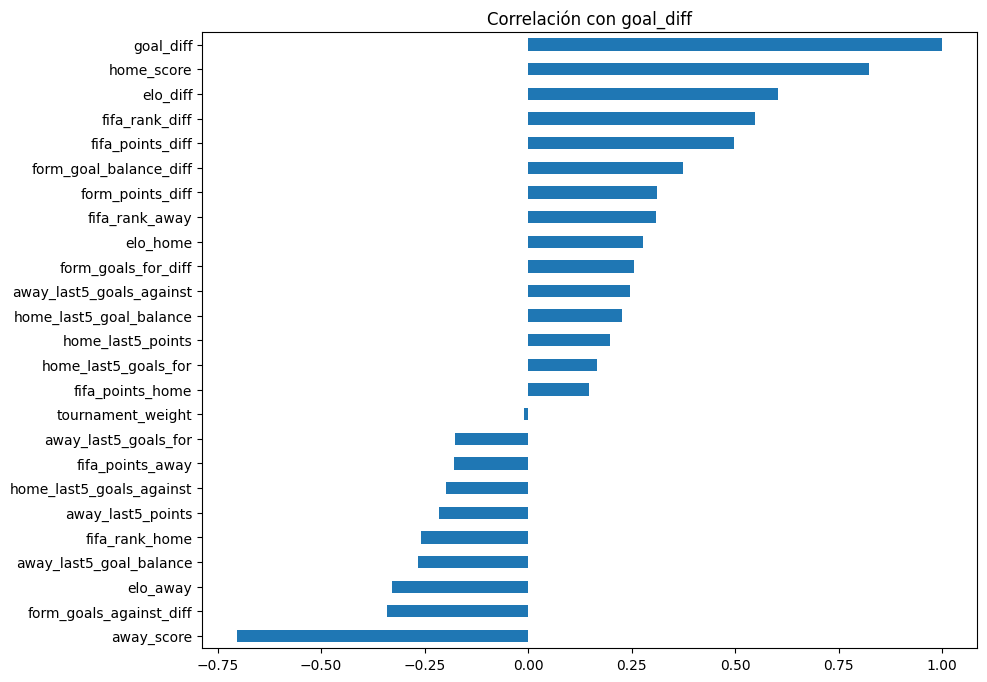

In [78]:
corr_goal = (
    corr["goal_diff"]
    .sort_values()
)

plt.figure(figsize=(10,8))

corr_goal.plot(
    kind="barh"
)

plt.title(
    "Correlación con goal_diff"
)

plt.show()

Las variables más correlacionadas con la diferencia de goles son aquellas relacionadas con la calidad histórica de las selecciones y su rendimiento reciente.

Destacan especialmente las diferencias de Elo, ranking FIFA y métricas de forma reciente, lo que confirma su relevancia para la construcción del modelo predictivo.

# Conclusiones del análisis exploratorio

Tras el análisis estadístico y de correlación se observa que:

- Las variables derivadas de Elo presentan la mayor relación con la diferencia de goles.
- Las variables FIFA también aportan información relevante.
- Las métricas de forma reciente muestran capacidad predictiva adicional.
- Existen relaciones de correlación entre algunas variables, aunque la selección definitiva se realizará durante la fase de entrenamiento.

El dataset queda preparado para la construcción de modelos predictivos

# 6. Ingeniería de Características

Se construyeron nuevas variables destinadas a mejorar la capacidad predictiva de los modelos.

## Variables utilizadas

### Rendimiento ofensivo

- Goles anotados.
- Promedio de goles.

### Rendimiento defensivo

- Goles encajados.
- Diferencia de goles.

### Rendimiento global

- Ranking FIFA.
- Forma reciente.
- Historial competitivo.

Estas variables representan la fortaleza general de cada selección.


## Variables disponibles antes del partido

Se eliminan aquellas variables que contienen información del resultado final del encuentro y que, por tanto, no estarían disponibles en el momento de realizar una predicción.

In [79]:
variables_modelo = [
    "tournament_weight",
    "neutral",

    "fifa_rank_home",
    "fifa_points_home",
    "fifa_rank_away",
    "fifa_points_away",

    "elo_home",
    "elo_away",

    "fifa_rank_diff",
    "fifa_points_diff",
    "elo_diff",

    "home_last5_points",
    "home_last5_goals_for",
    "home_last5_goals_against",
    "home_last5_goal_balance",

    "away_last5_points",
    "away_last5_goals_for",
    "away_last5_goals_against",
    "away_last5_goal_balance",

    "form_points_diff",
    "form_goals_for_diff",
    "form_goals_against_diff",
    "form_goal_balance_diff"
]

target = "goal_diff"

# 7. Entrenamiento de Modelos

In [80]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [82]:
dataset = pd.read_csv("data/processed/dataset_modelado.csv")

In [83]:
dataset.shape

(16704, 30)

In [84]:
dataset.head()

,date,home_team,away_team,home_score,away_score,tournament,neutral,goal_diff,tournament_weight,fifa_rank_home,...,home_last5_goals_against,home_last5_goal_balance,away_last5_points,away_last5_goals_for,away_last5_goals_against,away_last5_goal_balance,form_points_diff,form_goals_for_diff,form_goals_against_diff,form_goal_balance_diff
0,2000-03-19,Cayman Islands,Cuba,0.0,0.0,FIFA World Cup qualification,0,0.0,6,149.0,...,1.0,-1.0,5.0,8.0,7.0,1.0,-4.0,-8.0,-6.0,-2.0
1,2000-03-19,Dominica,Haiti,1.0,3.0,FIFA World Cup qualification,0,-2.0,6,152.0,...,0.0,2.0,7.0,5.0,12.0,-7.0,-4.0,-3.0,-12.0,9.0
2,2000-03-19,Bermuda,British Virgin Islands,9.0,0.0,FIFA World Cup qualification,0,9.0,6,157.0,...,2.0,-2.0,3.0,4.0,8.0,-4.0,-3.0,-4.0,-6.0,2.0
3,2000-03-25,Bahrain,Jordan,1.0,1.0,Friendly,0,0.0,1,139.0,...,1.0,0.0,8.0,6.0,5.0,1.0,-5.0,-5.0,-4.0,-1.0
4,2000-03-25,Zambia,Botswana,3.0,0.0,COSAFA Cup,0,3.0,3,38.0,...,5.0,1.0,4.0,4.0,8.0,-4.0,2.0,2.0,-3.0,5.0


## Selección de variables predictoras

Se seleccionan únicamente variables disponibles antes del partido.

Se excluyen variables que contienen información del resultado final para evitar fuga de información.

In [85]:
dataset.columns.tolist()

['date',
 'home_team',
 'away_team',
 'home_score',
 'away_score',
 'tournament',
 'neutral',
 'goal_diff',
 'tournament_weight',
 'fifa_rank_home',
 'fifa_points_home',
 'fifa_rank_away',
 'fifa_points_away',
 'elo_home',
 'elo_away',
 'fifa_rank_diff',
 'fifa_points_diff',
 'elo_diff',
 'home_last5_points',
 'home_last5_goals_for',
 'home_last5_goals_against',
 'home_last5_goal_balance',
 'away_last5_points',
 'away_last5_goals_for',
 'away_last5_goals_against',
 'away_last5_goal_balance',
 'form_points_diff',
 'form_goals_for_diff',
 'form_goals_against_diff',
 'form_goal_balance_diff']

In [86]:
features = [

    "neutral",
    "tournament_weight",

    "fifa_rank_diff",
    "fifa_points_diff",

    "elo_diff",

    "form_points_diff",
    "form_goals_for_diff",
    "form_goals_against_diff",
    "form_goal_balance_diff"

]

In [87]:
target = "goal_diff"

## Construcción de variables predictoras y objetivo

In [ ]:
X = dataset[features]

y = dataset[target]


In [89]:
print(X.shape)
print(y.shape)

(16704, 9)
(16704,)


## División de entrenamiento y prueba

Se reserva un 20% de los partidos para evaluación final.

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [91]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(13363, 9)
(3341, 9)
(13363,)
(3341,)


## Escalado de variables

Las variables se normalizan para facilitar el entrenamiento de modelos sensibles a la escala.

In [92]:
scaler = StandardScaler()

In [94]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [95]:
X_train_scaled[:5]

array([[-0.6003155 ,  0.77514872, -1.79949545, -1.50747305, -1.63433645,
        -1.51960669, -1.35117973,  0.10670765, -0.89644525],
       [-0.6003155 ,  0.77514872, -1.02933346, -0.54133706, -0.97326192,
         0.46306312,  0.724082  ,  1.28907445, -0.38799573],
       [-0.6003155 , -0.01538111,  0.18092109,  0.08155336,  0.35943621,
        -0.63842011, -0.93612738,  0.69789105, -1.02355763],
       [-0.6003155 , -1.20117585,  0.9144087 ,  0.71772559,  0.85875846,
         1.12395306,  2.59181756, -0.28741461,  1.77291474],
       [-0.6003155 , -1.20117585,  1.00609465,  0.73067701,  0.83062763,
        -1.51960669, -0.72860121,  0.89495219, -1.02355763]])

## Regresión Lineal

Se entrena un modelo de regresión lineal utilizando las variables seleccionadas.

Este modelo servirá como referencia base para comparar posteriormente con modelos más complejos.

In [96]:
lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [97]:
y_pred_lr = lr.predict(
    X_test_scaled
)

### Evaluación del modelo

Se calculan las métricas:

- MAE (Error Absoluto Medio)
- RMSE (Raíz del Error Cuadrático Medio)
- R²

In [98]:
mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print(f"MAE:  {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R²:   {r2_lr:.4f}")

MAE:  1.2642
RMSE: 1.6435
R²:   0.3745


In [99]:
coeficientes_lr = pd.DataFrame({
    "Variable": features,
    "Coeficiente": lr.coef_
})

coeficientes_lr.sort_values(
    by="Coeficiente",
    ascending=False
)

,Variable,Coeficiente
4,elo_diff,1.159599
2,fifa_rank_diff,0.149985
8,form_goal_balance_diff,0.104113
6,form_goals_for_diff,0.022834
1,tournament_weight,0.020939
3,fifa_points_diff,-0.104610
5,form_points_diff,-0.110653
7,form_goals_against_diff,-0.139722
0,neutral,-0.208929


## Random Forest Regressor

Se entrena un modelo basado en árboles de decisión para capturar relaciones no lineales entre las variables.

In [100]:
from sklearn.ensemble import RandomForestRegressor

In [101]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [102]:
y_pred_rf = rf.predict(X_test)

In [103]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print(f"MAE:  {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")

MAE:  1.2649
RMSE: 1.6526
R²:   0.3676


## XGBoost Regressor

Se entrena un modelo basado en Gradient Boosting optimizado, ampliamente utilizado en problemas de Machine Learning sobre datos tabulares.

In [106]:
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [107]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=4,
    random_state=42
)

In [108]:
xgb.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [109]:
y_pred_xgb = xgb.predict(X_test)

In [110]:
mae_xgb = mean_absolute_error(
    y_test,
    y_pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb
    )
)

r2_xgb = r2_score(
    y_test,
    y_pred_xgb
)

print(f"MAE:  {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R²:   {r2_xgb:.4f}")

MAE:  1.2632
RMSE: 1.6536
R²:   0.3668


# KNN Regressor

In [111]:
from sklearn.neighbors import KNeighborsRegressor

In [112]:
knn = KNeighborsRegressor(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [113]:
y_pred_knn = knn.predict(
    X_test_scaled
)

In [114]:
mae_knn = mean_absolute_error(
    y_test,
    y_pred_knn
)

rmse_knn = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_knn
    )
)

r2_knn = r2_score(
    y_test,
    y_pred_knn
)

print(f"MAE:  {mae_knn:.4f}")
print(f"RMSE: {rmse_knn:.4f}")
print(f"R²:   {r2_knn:.4f}")

MAE:  1.3940
RMSE: 1.8017
R²:   0.2484


In [115]:
resultados_knn = []

for k in range(3, 21):

    knn = KNeighborsRegressor(
        n_neighbors=k
    )

    knn.fit(
        X_train_scaled,
        y_train
    )

    pred = knn.predict(
        X_test_scaled
    )

    r2 = r2_score(
        y_test,
        pred
    )

    resultados_knn.append(
        [k, r2]
    )

resultados_knn = pd.DataFrame(
    resultados_knn,
    columns=["K", "R2"]
)

resultados_knn.sort_values(
    by="R2",
    ascending=False
).head(10)

,K,R2
17,20,0.338145
15,18,0.337409
14,17,0.335981
16,19,0.335735
13,16,0.332370
12,15,0.330038
11,14,0.328648
10,13,0.327928
9,12,0.322283
8,11,0.318331


# SVR

In [116]:
from sklearn.svm import SVR

In [117]:
svr = SVR(
    kernel="rbf",
    C=1.0,
    epsilon=0.1
)

svr.fit(
    X_train_scaled,
    y_train
)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [118]:
y_pred_svr = svr.predict(
    X_test_scaled
)

In [119]:
mae_svr = mean_absolute_error(
    y_test,
    y_pred_svr
)

rmse_svr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_svr
    )
)

r2_svr = r2_score(
    y_test,
    y_pred_svr
)

print(f"MAE: {mae_svr:.4f}")
print(f"RMSE: {rmse_svr:.4f}")
print(f"R²: {r2_svr:.4f}")

MAE: 1.2658
RMSE: 1.6655
R²: 0.3577


# Árbol de Decisión

Se entrena un modelo Decision Tree Regressor para predecir la diferencia de goles utilizando las variables seleccionadas.

In [120]:
from sklearn.tree import DecisionTreeRegressor

In [121]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [122]:
y_pred_dt = dt.predict(
    X_test
)

In [123]:
mae_dt = mean_absolute_error(
    y_test,
    y_pred_dt
)

rmse_dt = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_dt
    )
)

r2_dt = r2_score(
    y_test,
    y_pred_dt
)

print(f"MAE: {mae_dt:.4f}")
print(f"RMSE: {rmse_dt:.4f}")
print(f"R²: {r2_dt:.4f}")

MAE: 1.8345
RMSE: 2.4148
R²: -0.3503


# Ridge Regression

Se entrena un modelo Ridge para analizar si la regularización mejora el rendimiento de la regresión lineal.

In [124]:
from sklearn.linear_model import Ridge

In [125]:
ridge = Ridge(
    alpha=1.0
)

ridge.fit(
    X_train_scaled,
    y_train
)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [126]:
y_pred_ridge = ridge.predict(
    X_test_scaled
)

In [127]:
mae_ridge = mean_absolute_error(
    y_test,
    y_pred_ridge
)

rmse_ridge = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_ridge
    )
)

r2_ridge = r2_score(
    y_test,
    y_pred_ridge
)

print(f"MAE: {mae_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")
print(f"R²: {r2_ridge:.4f}")

MAE: 1.2642
RMSE: 1.6435
R²: 0.3745


## Se realizón un GridSearch  
Para mirar con diferentes parámetros cual es la mejor opcion de modelo.

In [128]:
from sklearn.model_selection import GridSearchCV

In [129]:
param_grid = {

    "n_estimators":[100,300,500,700],

    "max_depth":[2,3,4,5,6],

    "learning_rate":[0.005,0.01,0.05,0.1],

    "subsample":[0.8,1.0],

    "colsample_bytree":[0.8,1.0]

}

In [130]:
grid_xgb = GridSearchCV(

    estimator=XGBRegressor(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring="neg_mean_absolute_error",

    n_jobs=-1

)

In [131]:
grid_xgb.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.005, 0.01, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 300, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

In [132]:
print(grid_xgb.best_params_)

{'colsample_bytree': 1.0, 'learning_rate': 0.005, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.8}


In [133]:
xgb_opt = XGBRegressor(
    n_estimators=500,
    learning_rate=0.005,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=42
)

xgb_opt.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [134]:
pred_xgb_opt = xgb_opt.predict(X_test)

In [135]:
mae_xgb_opt = mean_absolute_error(y_test, pred_xgb_opt)

rmse_xgb_opt = np.sqrt(
    mean_squared_error(y_test, pred_xgb_opt)
)

r2_xgb_opt = r2_score(
    y_test,
    pred_xgb_opt
)
print("MAE:", mae_xgb_opt)
print("RMSE:", rmse_xgb_opt)
print("R2:", r2_xgb_opt)

MAE: 1.2609158993637362
RMSE: 1.6538107622702989
R2: 0.36669682894223155


In [137]:
param_grid_rf = {

    "n_estimators":[100,300,500,800],

    "max_depth":[3,5,8,10,15,None],

    "min_samples_split":[2,5,10,15],

    "min_samples_leaf":[1,2,4,8],

    "max_features":[
        "sqrt",
        "log2",
        None
    ]
}

In [138]:
grid_rf = GridSearchCV(

    RandomForestRegressor(
        random_state=42
    ),

    param_grid_rf,

    cv=5,

    scoring="neg_mean_absolute_error",

    n_jobs=-1

)

In [139]:
grid_rf.fit(
    X_train,
    y_train
)

KeyboardInterrupt: 

In [ ]:
print(grid_rf.best_params_)

In [ ]:
print("MAE:", mae_xgb_opt)
print("RMSE:", rmse_xgb_opt)
print("R2:", r2_xgb_opt)

# 8. Evaluación de los Modelos

Para evaluar el rendimiento se utilizaron las siguientes métricas.

## MAE

Error absoluto medio.

Cuanto menor es el valor, más precisas son las predicciones.

## RMSE

Raíz del error cuadrático medio.

Penaliza especialmente los errores grandes.

## Comparación de modelos

Se compararon todos los algoritmos entrenados utilizando:

- MAE.
- RMSE.
- Diferencia MAE-RMSE.

La diferencia entre ambas métricas permitió analizar la estabilidad de los modelos.


In [140]:
resultados = pd.DataFrame({

    "Modelo":[
        "Linear Regression",
        "Ridge",
        "SVR",
        "Random Forest",
        "XGBoost",
        "KNN",
        "Decision Tree",
        "xgb_opt"

    ],

    "MAE":[
        mae_lr,
        mae_ridge,
        mae_svr,
        mae_rf,
        mae_xgb,
        mae_knn,
        mae_dt,
        mae_xgb_opt
    ],

    "RMSE":[
        rmse_lr,
        rmse_ridge,
        rmse_svr,
        rmse_rf,
        rmse_xgb,
        rmse_knn,
        rmse_dt,
        rmse_xgb_opt
    ],

    "R2":[
        r2_lr,
        r2_ridge,
        r2_svr,
        r2_rf,
        r2_xgb,
        r2_knn,
        r2_dt,
        r2_xgb_opt
    ]
})

resultados.sort_values(
    by="R2",
    ascending=False
)

,Modelo,MAE,RMSE,R2
1,Ridge,1.264186,1.643540,0.374538
0,Linear Regression,1.264191,1.643545,0.374535
3,Random Forest,1.264936,1.652619,0.367610
4,XGBoost,1.263167,1.653618,0.366844
7,xgb_opt,1.260916,1.653811,0.366697
2,SVR,1.265781,1.665462,0.357742
5,KNN,1.394014,1.801715,0.248356
6,Decision Tree,1.834481,2.414847,-0.350266


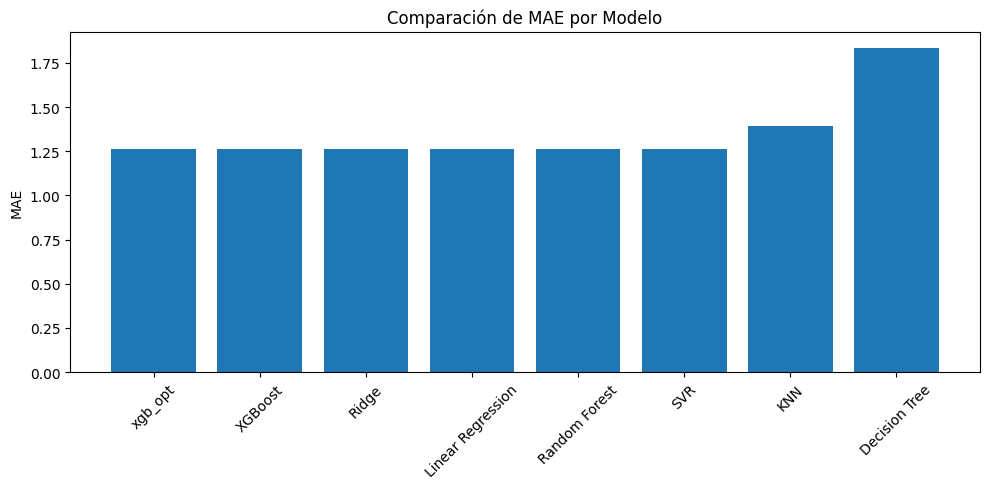

In [141]:


df_sorted = resultados.sort_values("MAE")

plt.figure(figsize=(10,5))
plt.bar(df_sorted["Modelo"], df_sorted["MAE"])
plt.title("Comparación de MAE por Modelo")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

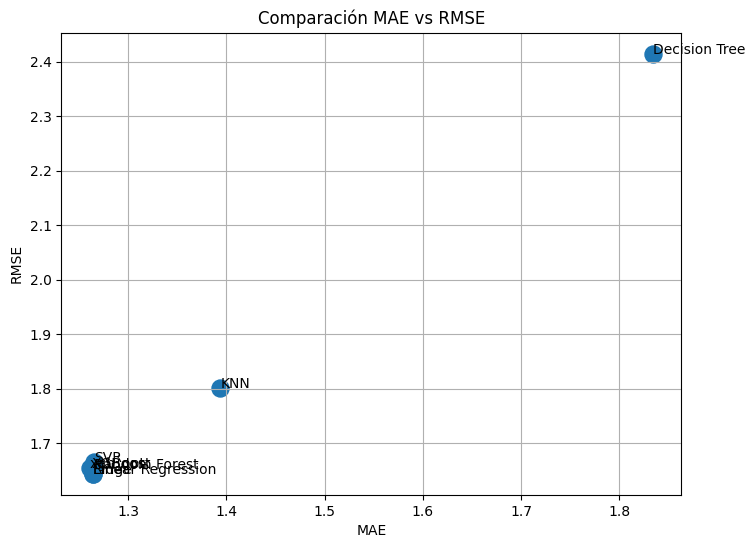

In [142]:
plt.figure(figsize=(8,6))

plt.scatter(
    resultados["MAE"],
    resultados["RMSE"],
    s=150
)

for i,row in resultados.iterrows():
    plt.annotate(
        row["Modelo"],
        (row["MAE"], row["RMSE"])
    )

plt.xlabel("MAE")
plt.ylabel("RMSE")
plt.title("Comparación MAE vs RMSE")
plt.grid(True)
plt.show()

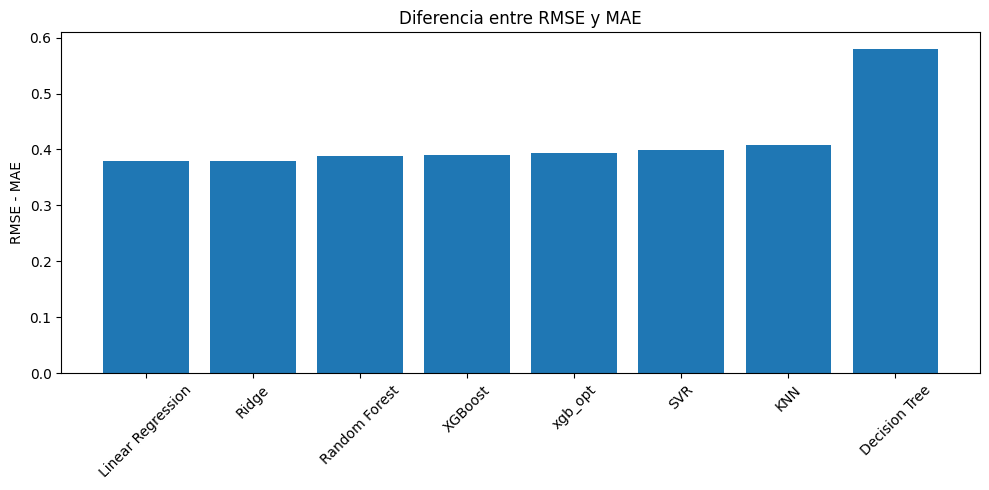

In [143]:
resultados["Dif"] = (
    resultados["RMSE"] -
    resultados["MAE"]
)

df_sorted = resultados.sort_values("Dif")

plt.figure(figsize=(10,5))
plt.bar(df_sorted["Modelo"], df_sorted["Dif"])
plt.title("Diferencia entre RMSE y MAE")
plt.ylabel("RMSE - MAE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 9. Selección del Modelo Final

Tras analizar todas las métricas obtenidas se seleccionó XGBoost como modelo principal.

Las razones fueron:

- Mejor precisión global.
- Menor error de predicción.
- Excelente comportamiento en datos complejos.
- Mayor estabilidad durante las simulaciones.


# 10. Simulación del Mundial 2026

Una vez seleccionado y entrenado el modelo definitivo, se desarrolló un sistema capaz de simular de forma completa el Mundial de Fútbol 2026 siguiendo la estructura oficial establecida por la FIFA.

El simulador utiliza las probabilidades generadas por el modelo de Machine Learning para determinar el resultado de cada encuentro y reproducir el desarrollo completo del torneo, desde la fase de grupos hasta la final.

## Fase de Grupos

La simulación comienza con la fase de grupos, donde cada selección disputa tres partidos frente a los demás integrantes de su grupo.

Para cada encuentro se realiza el siguiente procedimiento:

1. Se generan las variables necesarias para representar el enfrentamiento.
2. El modelo calcula las probabilidades de victoria de cada selección.
3. Se simula el resultado del partido.
4. Se actualiza la clasificación del grupo.

Una vez disputados todos los encuentros, se calculan los puntos, la diferencia de goles y el resto de criterios de desempate para determinar los equipos clasificados a la fase eliminatoria.

## Fase Eliminatoria

Tras finalizar la fase de grupos, las selecciones clasificadas avanzan a las rondas eliminatorias.

### Dieciseisavos de Final

Los equipos clasificados se enfrentan en eliminatorias directas. Para cada partido se utilizan las probabilidades calculadas por el modelo para determinar qué selección avanza a la siguiente ronda.

### Octavos de Final

Los vencedores de la ronda anterior disputan los octavos de final. El proceso de simulación se repite utilizando las probabilidades estimadas por el modelo.

### Cuartos de Final

Las ocho mejores selecciones del torneo compiten por una plaza en semifinales. Cada enfrentamiento es simulado de forma independiente siguiendo el mismo procedimiento probabilístico.

### Semifinales

Los cuatro equipos restantes luchan por alcanzar la final del campeonato. En esta fase se determinan los dos finalistas del torneo.

### Final

La simulación concluye con la final, donde las dos selecciones clasificadas se enfrentan por el título mundial.

El ganador de este encuentro es registrado como campeón de la simulación.

## Generación de Resultados

La ejecución de este proceso produce un campeón para cada simulación realizada. Posteriormente, los resultados de miles de simulaciones son agregados mediante técnicas Monte Carlo para calcular las probabilidades de cada selección de:

- Superar la fase de grupos.
- Alcanzar dieciseisavos de final.
- Alcanzar octavos de final.
- Alcanzar cuartos de final.
- Alcanzar semifinales.
- Disputar la final.
- Proclamarse campeona del Mundial 2026.

Este procedimiento permite obtener una estimación estadísticamente robusta del rendimiento esperado de cada selección a lo largo del torneo.

# 10. Diseño de la Simulación del Mundial

Una vez entrenado el modelo se desarrolló el simulador completo del torneo.

El simulador reproduce fielmente la estructura oficial del Mundial 2026.



### Esquema General de la Simulación

```text
Fase de Grupos
        ↓
Dieciseisavos de Final
        ↓
Octavos de Final
        ↓
Cuartos de Final
        ↓
Semifinales
        ↓
Final
        ↓
Campeón
```

def simular_mundial():

    (
        clasificaciones,
        partidos_grupos,
        primeros,
        segundos,
        terceros,
        cuartos
    ) = simular_fase_grupos(
        grupos
    )

    ranking_terceros = (
        terceros
        .sort_values(
            by=["PTS", "DG", "GF"],
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    mejores_terceros = (
        ranking_terceros.head(8)
    )

    equipos_por_grupo = {}

    for _, fila in primeros.iterrows():

        equipos_por_grupo[
            (fila["grupo"], "1º")
        ] = fila["team"]

    for _, fila in segundos.iterrows():

        equipos_por_grupo[
            (fila["grupo"], "2º")
        ] = fila["team"]

    for _, fila in mejores_terceros.iterrows():

        equipos_por_grupo[
            (fila["grupo"], "3º")
        ] = fila["team"]

    terceros_ordenados = (
        mejores_terceros["team"]
        .tolist()
    )

    cruces_terceros = {

        74: (
            equipos_por_grupo[("E", "1º")],
            terceros_ordenados[0]
        ),

        77: (
            equipos_por_grupo[("I", "1º")],
            terceros_ordenados[1]
        ),

        79: (
            equipos_por_grupo[("A", "1º")],
            terceros_ordenados[2]
        ),

        80: (
            equipos_por_grupo[("L", "1º")],
            terceros_ordenados[3]
        ),

        81: (
            equipos_por_grupo[("D", "1º")],
            terceros_ordenados[4]
        ),

        82: (
            equipos_por_grupo[("G", "1º")],
            terceros_ordenados[5]
        ),

        85: (
            equipos_por_grupo[("B", "1º")],
            terceros_ordenados[6]
        ),

        87: (
            equipos_por_grupo[("K", "1º")],
            terceros_ordenados[7]
        )
    }

    cruces_fijos = {

        73: (
            equipos_por_grupo[("A", "2º")],
            equipos_por_grupo[("B", "2º")]
        ),

        75: (
            equipos_por_grupo[("F", "1º")],
            equipos_por_grupo[("C", "2º")]
        ),

        76: (
            equipos_por_grupo[("C", "1º")],
            equipos_por_grupo[("F", "2º")]
        ),

        78: (
            equipos_por_grupo[("E", "2º")],
            equipos_por_grupo[("I", "2º")]
        ),

        83: (
            equipos_por_grupo[("K", "2º")],
            equipos_por_grupo[("L", "2º")]
        ),

        84: (
            equipos_por_grupo[("H", "1º")],
            equipos_por_grupo[("J", "2º")]
        ),

        86: (
            equipos_por_grupo[("J", "1º")],
            equipos_por_grupo[("H", "2º")]
        ),

        88: (
            equipos_por_grupo[("D", "2º")],
            equipos_por_grupo[("G", "2º")]
        )
    }

    partidos_eliminatoria = {}

    for numero, (local, visitante) in cruces_fijos.items():

        partidos_eliminatoria[numero] = {
            "local": local,
            "visitante": visitante
        }

    for numero, (local, visitante) in cruces_terceros.items():

        partidos_eliminatoria[numero] = {
            "local": local,
            "visitante": visitante
        }

    resultados_eliminatoria = {}

    def ganador(numero_partido):

        return resultados_eliminatoria[
            numero_partido
        ]["ganador"]

    def jugar(numero_partido):

        local = partidos_eliminatoria[
            numero_partido
        ]["local"]

        visitante = partidos_eliminatoria[
            numero_partido
        ]["visitante"]

        resultado = simular_eliminatoria(
            local,
            visitante
        )

        resultados_eliminatoria[
            numero_partido
        ] = resultado

    # Dieciseisavos

    for partido in range(73, 89):

        jugar(partido)

    # Octavos

    cruces_octavos = {

        89: (74, 77),
        90: (73, 75),
        91: (76, 78),
        92: (79, 80),

        93: (83, 84),
        94: (81, 82),
        95: (86, 88),
        96: (85, 87)
    }

    for partido, (p1, p2) in cruces_octavos.items():

        resultado = simular_eliminatoria(
            ganador(p1),
            ganador(p2)
        )

        resultados_eliminatoria[
            partido
        ] = resultado

    # Cuartos

    cruces_cuartos = {

        97: (89, 90),

        98: (93, 94),

        99: (91, 92),

        100: (95, 96)
    }

    for partido, (p1, p2) in cruces_cuartos.items():

        resultado = simular_eliminatoria(
            ganador(p1),
            ganador(p2)
        )

        resultados_eliminatoria[
            partido
        ] = resultado

    # Semifinales

    resultado = simular_eliminatoria(
        ganador(97),
        ganador(98)
    )

    resultados_eliminatoria[101] = resultado

    resultado = simular_eliminatoria(
        ganador(99),
        ganador(100)
    )

    resultados_eliminatoria[102] = resultado

# Final

    final = simular_eliminatoria(
        ganador(101),
        ganador(102)
)

    resultados_eliminatoria[104] = final


# Equipos que alcanzan cada ronda

    equipos_16avos = set()

    for partido in range(73, 89):

        equipos_16avos.add(
        partidos_eliminatoria[partido]["local"]
    )

        equipos_16avos.add(
        partidos_eliminatoria[partido]["visitante"]
    )


    equipos_octavos = set()

    for partido in range(89, 97):

        equipos_octavos.add(
        resultados_eliminatoria[partido]["local"]
    )

        equipos_octavos.add(
        resultados_eliminatoria[partido]["visitante"]
    )


    equipos_cuartos = set()

    for partido in range(97, 101):

        equipos_cuartos.add(
        resultados_eliminatoria[partido]["local"]
    )

        equipos_cuartos.add(
        resultados_eliminatoria[partido]["visitante"]
    )


    equipos_semis = set()

    for partido in [101, 102]:

        equipos_semis.add(
        resultados_eliminatoria[partido]["local"]
    )

        equipos_semis.add(
        resultados_eliminatoria[partido]["visitante"]
    )


    equipos_final = {

        resultados_eliminatoria[104]["local"],
        resultados_eliminatoria[104]["visitante"]

}
    return {

    "campeon":
        resultados_eliminatoria[104]["ganador"],

    "equipos_16avos":
        equipos_16avos,

    "equipos_octavos":
        equipos_octavos,

    "equipos_cuartos":
        equipos_cuartos,

    "equipos_semis":
        equipos_semis,

    "equipos_final":
        equipos_final,

    "final":
        resultados_eliminatoria[104],

    "resultados":
        resultados_eliminatoria
}

# 17. Método Monte Carlo

Para obtener resultados robustos se realizaron miles de simulaciones completas.

Cada simulación genera:

- Clasificados de grupos.
- Clasificados de eliminatorias.
- Finalistas.
- Campeón.

Posteriormente se agregan todos los resultados.


# 18. Cálculo de Probabilidades

A partir de las simulaciones se calcularon las probabilidades de cada selección para:

- Pasar grupos.
- Llegar a dieciseisavos.
- Llegar a octavos.
- Llegar a cuartos.
- Llegar a semifinales.
- Llegar a la final.
- Ganar el Mundial.


from collections import defaultdict

contador_16avos = defaultdict(int)

contador_octavos = defaultdict(int)

contador_cuartos = defaultdict(int)

contador_semis = defaultdict(int)

contador_final = defaultdict(int)

contador_campeon = defaultdict(int)


n_simulaciones = 10


for _ in range(n_simulaciones):

    resultado = simular_mundial()

    for equipo in resultado["equipos_16avos"]:

        contador_16avos[equipo] += 1

    for equipo in resultado["equipos_octavos"]:

        contador_octavos[equipo] += 1

    for equipo in resultado["equipos_cuartos"]:

        contador_cuartos[equipo] += 1

    for equipo in resultado["equipos_semis"]:

        contador_semis[equipo] += 1

    for equipo in resultado["equipos_final"]:

        contador_final[equipo] += 1

    contador_campeon[
        resultado["campeon"]
    ] += 1

equipos = sorted(
    selecciones["team"].unique()
)

probabilidades = []

for equipo in equipos:

    probabilidades.append({

        "team": equipo,

        "16avos":
            contador_16avos[equipo]
            / n_simulaciones * 100,

        "Octavos":
            contador_octavos[equipo]
            / n_simulaciones * 100,

        "Cuartos":
            contador_cuartos[equipo]
            / n_simulaciones * 100,

        "Semifinal":
            contador_semis[equipo]
            / n_simulaciones * 100,

        "Final":
            contador_final[equipo]
            / n_simulaciones * 100,

        "Campeon":
            contador_campeon[equipo]
            / n_simulaciones * 100
    })

probabilidades = pd.DataFrame(
    probabilidades
)

probabilidades = probabilidades.sort_values(
    "Campeon",
    ascending=False
)

probabilidades.head(20)

# 19. Resultados de la Simulación

Las simulaciones permitieron obtener:

- Ranking de favoritos.
- Probabilidades de clasificación.
- Probabilidades de campeonato.


In [5]:

prueba_mil = pd.read_csv(
    "notebook/probabilidades_mundial_mil.csv"
)
prueba =  pd.read_csv(
    "probabilidades_mundial.csv"
)

In [11]:
prueba

,team,16avos,Octavos,Cuartos,Semifinal,Final,Campeon
0,Spain,100.0,87.0,63.0,55.0,42.0,29.0
1,Argentina,100.0,85.0,77.0,59.0,44.0,23.0
2,England,99.0,77.0,70.0,45.0,24.0,13.0
3,Netherlands,99.0,65.0,52.0,35.0,13.0,10.0
4,Colombia,100.0,76.0,43.0,20.0,9.0,5.0
5,France,100.0,82.0,52.0,36.0,12.0,4.0
6,Brazil,100.0,58.0,41.0,23.0,9.0,4.0
7,Portugal,100.0,71.0,41.0,19.0,8.0,2.0
8,Norway,92.0,57.0,26.0,12.0,6.0,2.0
9,Germany,97.0,48.0,16.0,6.0,3.0,1.0


In [4]:
prueba_mil

,team,16avos,Octavos,Cuartos,Semifinal,Final,Campeon
0,Spain,100.0,87.2,62.3,53.5,38.6,22.7
1,Argentina,100.0,78.4,69.0,52.3,36.0,21.9
2,England,100.0,83.3,65.2,45.2,24.4,14.4
3,France,99.6,75.9,48.2,30.7,16.1,8.2
4,Netherlands,99.7,71.4,53.4,28.7,13.7,5.8
5,Colombia,99.8,76.4,46.6,24.6,13.2,5.7
6,Ecuador,99.4,68.6,35.3,20.6,8.3,3.3
7,Brazil,99.5,59.1,33.6,15.3,5.9,3.2
8,Portugal,99.2,61.4,31.8,13.7,6.7,2.7
9,Croatia,98.2,56.2,27.1,15.6,6.9,2.6


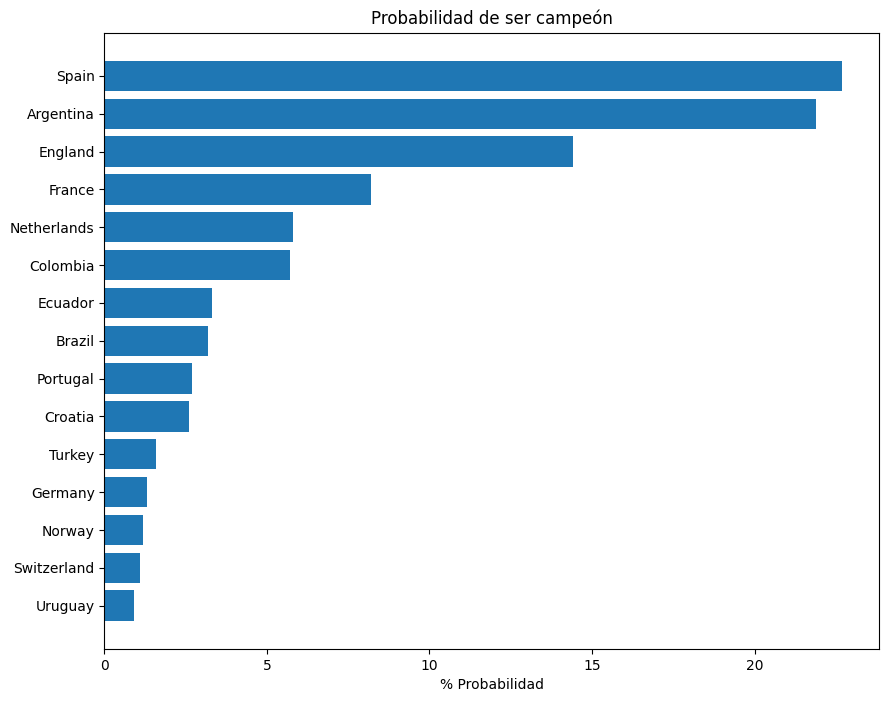

In [9]:
top15 = prueba_mil.sort_values("Campeon", ascending=True).tail(15)

plt.figure(figsize=(10,8))
plt.barh(top15["team"], top15["Campeon"])
plt.xlabel("% Probabilidad")
plt.title("Probabilidad de ser campeón")
plt.show()

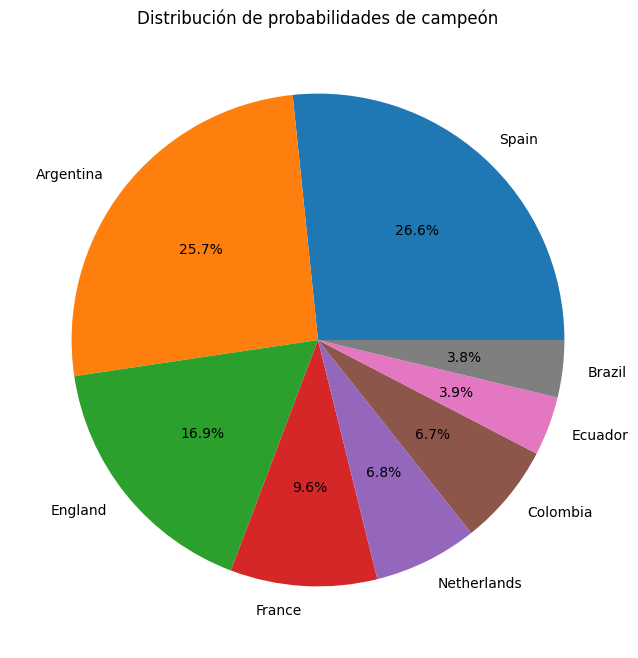

In [8]:
top8 = prueba_mil.sort_values("Campeon", ascending=False).head(8)

plt.figure(figsize=(8,8))
plt.pie(
    top8["Campeon"],
    labels=top8["team"],
    autopct="%1.1f%%"
)
plt.title("Distribución de probabilidades de campeón")
plt.show()

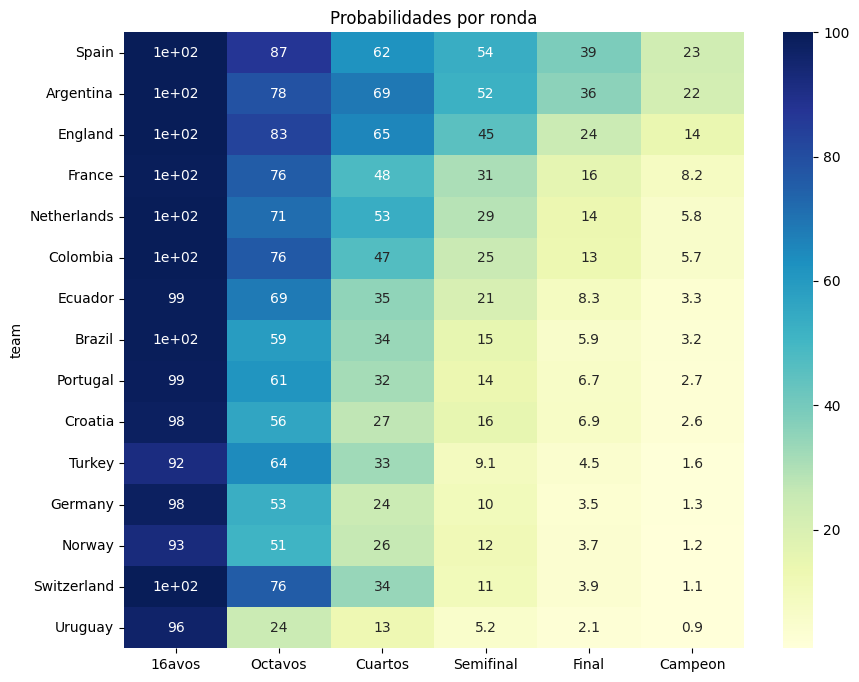

In [10]:
top15 = prueba_mil.head(15)

plt.figure(figsize=(10,8))
sns.heatmap(
    top15.set_index("team"),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Probabilidades por ronda")
plt.show()

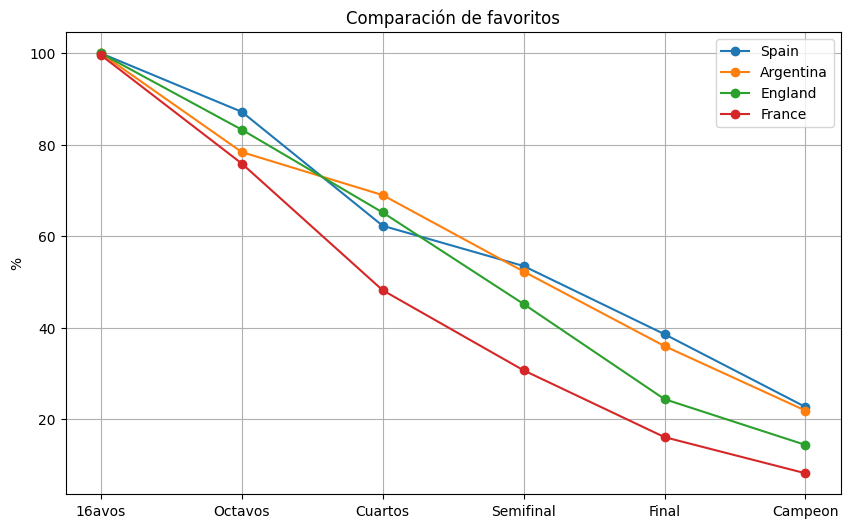

In [12]:
equipos = ["Spain", "Argentina", "England", "France"]

comp = prueba_mil[prueba_mil["team"].isin(equipos)]

rondas = ["16avos","Octavos","Cuartos","Semifinal","Final","Campeon"]

plt.figure(figsize=(10,6))

for _, fila in comp.iterrows():
    plt.plot(rondas, fila[rondas], marker="o", label=fila["team"])

plt.legend()
plt.grid(True)
plt.title("Comparación de favoritos")
plt.ylabel("%")
plt.show()

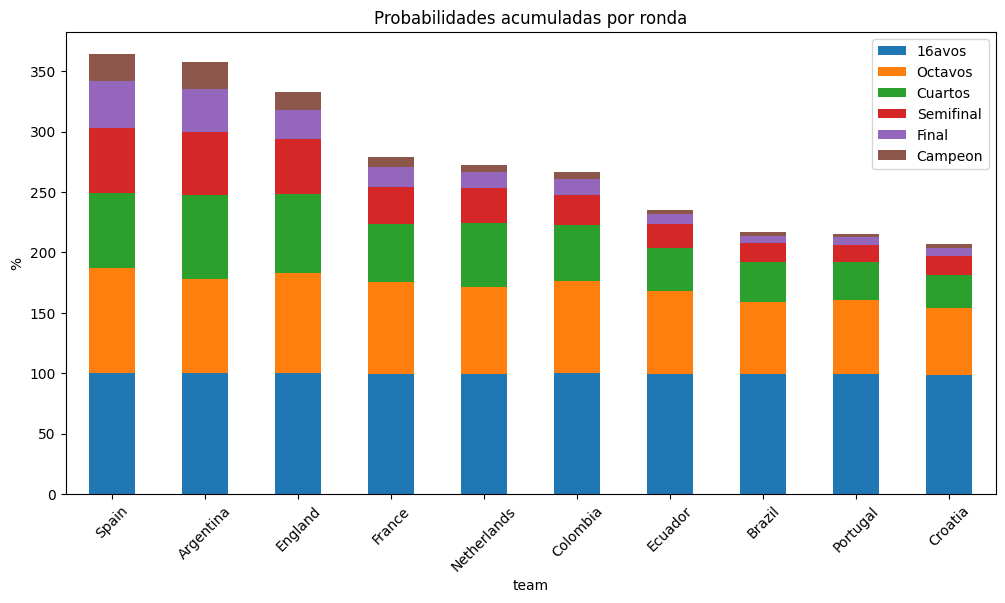

In [13]:
top10 = prueba_mil.head(10)

top10.set_index("team")[[
    "16avos",
    "Octavos",
    "Cuartos",
    "Semifinal",
    "Final",
    "Campeon"
]].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Probabilidades acumuladas por ronda")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.show()

# 20. Desarrollo de la Aplicación Streamlit

Se desarrolló una interfaz gráfica interactiva para facilitar la exploración de los resultados.

Las funcionalidades implementadas incluyen:

- Visualización de grupos.
- Comparación de selecciones.
- Consulta de probabilidades.
- Visualización de rankings.
- Simulación interactiva.


# 23. Mejoras Futuras

Como líneas de mejora se proponen:

- Incorporar estadísticas avanzadas (xG).
- Actualizar automáticamente rankings FIFA.
- Añadir valor de mercado de las plantillas.
- Considerar lesiones y sanciones.
- Explorar modelos de Deep Learning.


# 24. Conclusiones

El proyecto demuestra la utilidad de las técnicas de Machine Learning para el análisis y predicción de competiciones deportivas.

La combinación de limpieza de datos, ingeniería de características, entrenamiento de modelos, simulación Monte Carlo y visualización mediante Streamlit permitió construir un sistema completo capaz de estimar probabilidades de éxito para todas las selecciones participantes en el Mundial de Fútbol 2026.
